In [131]:
import numpy as np
import matplotlib.pyplot as plt
import h5py 
import sys 
import os, glob

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works

plt.style.use('../../utils/dune.mplstyle')

import time 
from collections import defaultdict

In [132]:
file='/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/2x2_QGSP_BERT_HP_AmBe_1774119367_0_TIME_MOD.FLOW.hdf5'
h5_file = h5py.File(file,'r') 
print(f"This file keys: {h5_file.keys()}")

This file keys: <KeysViewHDF5 ['charge', 'combined', 'geometry_info', 'lar_info', 'light', 'mc_truth', 'run_info']>


In [133]:
trajectories = h5_file['mc_truth/trajectories/data']
segments = h5_file['mc_truth/segments/data']
vertex = h5_file['mc_truth/interactions/data']

charge_prompt_hits = h5_file['charge/calib_prompt_hits/data']
charge_prompt_hits_bt = h5_file['mc_truth/calib_prompt_hit_backtrack/data']

print(f"Trajectories keys: {trajectories.dtype.names}")
print(f"Segments keys: {segments.dtype.names}")
print(f"Charge hits keys {charge_prompt_hits.dtype.names}")
print(f"Charge hits bt keys {charge_prompt_hits_bt.dtype.names}")

Trajectories keys: ('event_id', 'vertex_id', 'traj_id', 'file_traj_id', 'parent_id', 'primary', 'E_start', 'pxyz_start', 'xyz_start', 't_start', 'E_end', 'pxyz_end', 'xyz_end', 't_end', 'pdg_id', 'start_process', 'start_subprocess', 'end_process', 'end_subprocess', 'dist_travel')
Segments keys: ('event_id', 'vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE', 't', 'y', 'x', 'z', 'n_photons')
Charge hits keys ('id', 'x', 'y', 'z', 't_drift', 'ts_pps', 'io_group', 'io_channel', 'chip_id', 'channel_id', 'Q_raw', 'Q', 'E', 'is_disabled')
Charge hits bt keys ('event_ids', 'segment_ids', 'fraction', 'file_traj_ids', 'fraction_traj')


In [134]:
charge_prompt_hits_bt[charge_prompt_hits_bt['event_ids'].flatten()==13]

array([([13], [13410,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1], [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00], [32, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1], [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
       ([13], [   -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -

In [135]:
phits, phits_bt = get_charge_event_hits(12,h5_file)
print(phits)
print(phits_bt)

[([13], [13410,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1], [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00], [32, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1], [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])
 ([13], [   -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    -1,    

In [136]:
list_seg_ids = []
for ievt in range(len(charge_prompt_hits_bt)):
    list_seg_ids.extend(np.unique(charge_prompt_hits_bt[ievt]['segment_ids']))

print(np.unique(list_seg_ids))

[    -1   1990   1991 ... 243505 243506 243515]


In [137]:
capture_times = []
total_gamma_E = []
gamma_E = []
n_gammas = [] 

In [138]:


for ev in np.unique(trajectories['event_id']):
    my_traj = trajectories[trajectories['event_id']==ev]
    my_vert = vertex[vertex['event_id']==ev]

    ar41_traj = my_traj[(my_traj['pdg_id']==1000180410) & (my_traj['start_process']==4) & (my_traj['start_subprocess']==131)]
    ar41_traj_id = ar41_traj['parent_id']



    capture_times.extend(my_traj[(my_traj['pdg_id']==1000180410) & (my_traj['start_process']==4) & (my_traj['start_subprocess']==131) ]['t_start'] - my_vert['t_event'])
    gamma_E.extend(my_traj[(my_traj['pdg_id']==22) & 
                           (my_traj['parent_id']==ar41_traj_id) &
                           (my_traj['start_process']==4) & 
                           (my_traj['start_subprocess']==131)]['E_start'])
    
    n_gammas.append(len(my_traj[(my_traj['pdg_id']==22) & 
                                (my_traj['parent_id']==ar41_traj_id) &
                                (my_traj['start_process']==4) & 
                                (my_traj['start_subprocess']==131)]['E_start']))
    
    total_gamma_E.append(np.sum(my_traj[(my_traj['pdg_id']==22) &
                                        (my_traj['parent_id']==ar41_traj_id) &
                                         (my_traj['start_process']==4) & 
                                         (my_traj['start_subprocess']==131)]['E_start']))

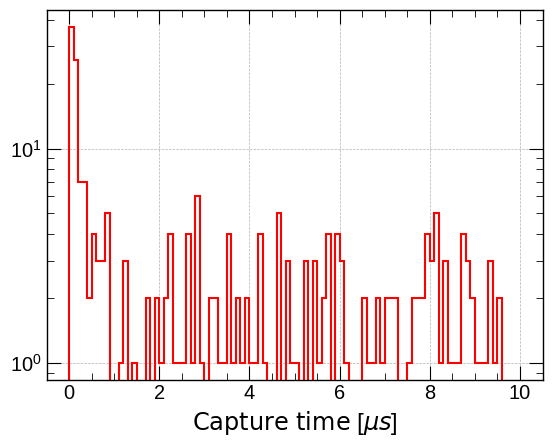

In [139]:
plt.hist(capture_times,bins=100,range=(0.,10),histtype='step',color='red')
plt.xlabel(r'$\text{Capture time}$ [$\mu s$]')
plt.yscale('log')
plt.grid()
plt.show()

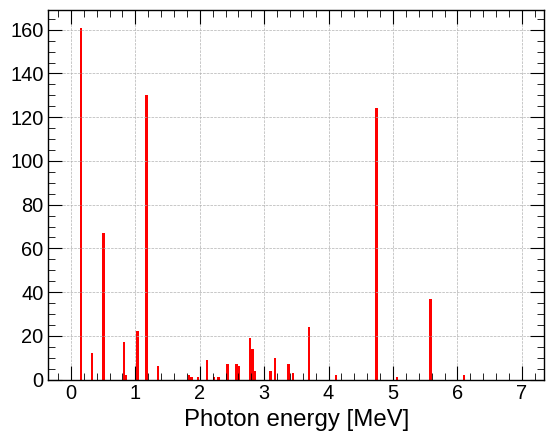

In [140]:
plt.hist(gamma_E,bins=200,range=(0.,7.),color='red')
plt.xlabel('Photon energy [MeV]')
plt.grid()
plt.show()

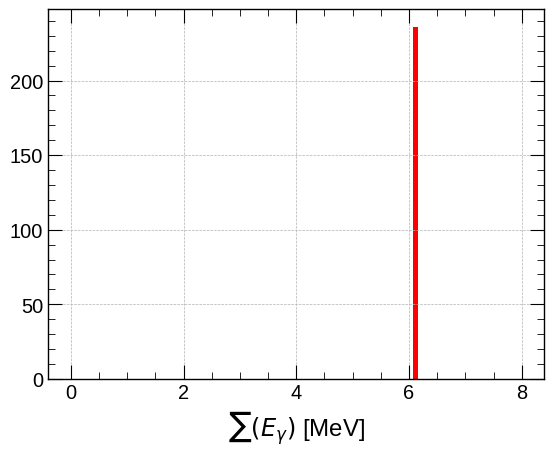

In [141]:
plt.hist(total_gamma_E,bins=100,range=(0.,8.),color='red')
plt.xlabel(r'$\sum(E_{\gamma})$ [MeV]')
plt.grid()
plt.show()

In [142]:
MC_sample_A = glob.glob("/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/*.FLOW.hdf5")
MC_sample_B = glob.glob("/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21_set_2/FLOW/*.FLOW.hdf5")
MC_sample_A.extend(MC_sample_B)
print(f"Number of MC files {len(MC_sample_A)}")

Number of MC files 166


In [ ]:
E_hits = []
E_sum_hits = []
Q_hits = []
Q_sum_hits = []

t_start = time.time()

n_evs = 0
n_ev_w_hits = 0
n_zero_hits = 0
n_negative_hits = 0

# Per-io containers
E_hits_io = defaultdict(list)
Q_hits_io = defaultdict(list)
E_cluster_io = defaultdict(list)

E_sum_capture = []
E_sum_inelastic = []
E_sum_neutron = []
E_sum_total = []

E_hit_sum_proc_capture = defaultdict(list)
E_hit_sum_proc_inelastic = defaultdict(list)

ifile_index = 0 
for this_file in MC_sample_A:
    #if(ifile_index>1):
    #    break
    with h5py.File(this_file, "r") as h5_file:
        events = h5_file['charge/events/data']
        vertex = h5_file['mc_truth/interactions/data'][:]
        trajectories = h5_file['mc_truth/trajectories/data'][:]
        segments = h5_file['mc_truth/segments/data'][:]

        print(f"Number of events in this file: {len(events)}")

        # Build inline lookup tables: event_id -> indices
        traj_lookup = defaultdict(list)
        for i, ev_id in enumerate(trajectories['event_id']):
            traj_lookup[ev_id].append(i)

        seg_lookup = defaultdict(list)
        for i, ev_id in enumerate(segments['event_id']):
            seg_lookup[ev_id].append(i)

        for ievent in range(len(events)):
            #if(ievent>100):
            #    break
            prompt_hbt, prompt_h = get_charge_event_hits(ievent, h5_file)

            n_evs += 1

            if len(prompt_h) == 0:
                n_zero_hits += 1
                continue

            this_ev_id = vertex['event_id'][ievent]

            # Fast lookup instead of scanning full arrays
            this_ev_traj = trajectories[traj_lookup[this_ev_id]]
            this_ev_segs = segments[seg_lookup[this_ev_id]]

            mc_hits = hit_backtracker(prompt_hbt, prompt_h, this_ev_segs, this_ev_traj)

            # Check alignment before filtering
            if len(mc_hits) != len(prompt_h):
                print("[WARNING] in this file/event, the number of mc hits isn't the same as the number of prompt hits")
                continue

            E = prompt_h['E']
            Q = prompt_h['Q']
            io = prompt_h['io_group']

            # Filter out negative-energy hits
            mask_valid = (E >= 0)
            n_negative_hits += np.sum(~mask_valid)

            prompt_h = prompt_h[mask_valid]
            prompt_hbt = prompt_hbt[mask_valid]
            mc_hits = mc_hits[mask_valid]

            E = prompt_h['E']
            Q = prompt_h['Q']
            io = prompt_h['io_group']

            # If all hits were negative, skip event
            if len(prompt_h) == 0:
                n_zero_hits += 1
                continue

            n_ev_w_hits += 1

            E_hits.extend(E)
            Q_hits.extend(Q)
            E_sum_hits.append(E.sum())
            Q_sum_hits.append(Q.sum())

            neutron_proc = mc_hits['neutron_process']
            mc_E = mc_hits['E']
            mc_proc = mc_hits['best_segment_p']

            mask_cap = (neutron_proc == 1)
            mask_inel = (neutron_proc == 0)
            mask_neu = (neutron_proc == 2)


            '''
            print(neutron_proc)
            print(f"Number of capture hits {np.sum(neutron_proc==1)}")
            print(f"Number of inelastic hits {np.sum((neutron_proc==0))}")
            print(f"Number of other hits {np.sum((neutron_proc==2))}")
            print(f"Number of all hits {len(prompt_h)}")
            print("---------------------------------------")
            '''

            E_cap = mc_E[mask_cap].sum()
            E_inel = mc_E[mask_inel].sum()
            E_neu = mc_E[mask_neu].sum()

            E_sum_total.append(E_cap + E_inel + E_neu)

            if E_cap > 0:
                E_sum_capture.append(E_cap)
                 # Get processes, and sum energy of hits  produced by the same process 
                unique_proc, inv = np.unique(mc_proc[mask_cap], return_inverse=True)
                E_sum_per_proc = np.bincount(inv, weights=mc_E[mask_cap])
                for i in range(len(unique_proc)):
                    E_hit_sum_proc_capture[unique_proc[i]].append(E_sum_per_proc[i])

            if E_inel > 0:
                E_sum_inelastic.append(E_inel)
                # Get processes, and sum energy of hits  produced by the same process 
                unique_proc, inv = np.unique(mc_proc[mask_inel], return_inverse=True)
                E_sum_per_proc = np.bincount(inv, weights=mc_E[mask_inel])

                for i in range(len(unique_proc)):
                    E_hit_sum_proc_inelastic[unique_proc[i]].append(E_sum_per_proc[i])

            if E_neu > 0:
                E_sum_neutron.append(E_neu)


            # Only loop over unique io groups
            for io_val in np.unique(io):
                mask = (io == io_val)
                E_io = E[mask]
                Q_io = Q[mask]

                E_hits_io[io_val].extend(E_io)
                Q_hits_io[io_val].extend(Q_io)
                E_cluster_io[io_val].append(E_io.sum())
    ifile_index+=1

print(f"Elapsed time {time.time() - t_start}")
print(f"Total events processed: {n_evs}")
print(f"Events with hits after filtering: {n_ev_w_hits}")
print(f"Events with zero hits: {n_zero_hits}")
print(f"Negative-energy hits removed: {n_negative_hits}")

Number of events in this file: 233
Number of events in this file: 212
Number of events in this file: 255
Number of events in this file: 221
Number of events in this file: 221
Number of events in this file: 245
Number of events in this file: 199
Number of events in this file: 220
Number of events in this file: 245
Number of events in this file: 218
Number of events in this file: 241
Number of events in this file: 238
Number of events in this file: 219
Number of events in this file: 238
Number of events in this file: 239
Number of events in this file: 234
Number of events in this file: 233
Number of events in this file: 223
Number of events in this file: 245
Number of events in this file: 232
Number of events in this file: 222
Number of events in this file: 237
Number of events in this file: 220
Number of events in this file: 234
Number of events in this file: 242
Number of events in this file: 227
Number of events in this file: 208
Number of events in this file: 225
Number of events in 

In [144]:
print(f"Fraction of events with zero hits {n_zero_hits/n_evs}")
print(f"Fraction of events with charge hits w negative energy: {n_negative_hits/n_evs}")

Fraction of events with zero hits 0.09152068724609931
Fraction of events with charge hits w negative energy: 0.14818744016353144


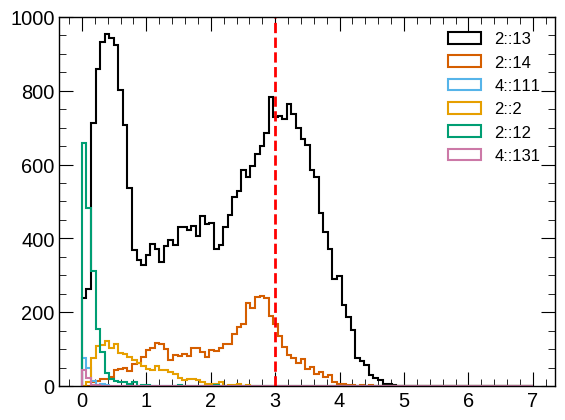

In [158]:
plt.figure()
my_bins = np.linspace(0,7,100)
for proc in E_hit_sum_proc_capture:
    if(proc=="-1::-1"):
        continue
    plt.hist(E_hit_sum_proc_capture[proc],bins=my_bins,histtype='step',label=proc)

#plt.yscale('log')    
plt.axvline(x=3,ls='--',color='red')
plt.legend()
plt.show()

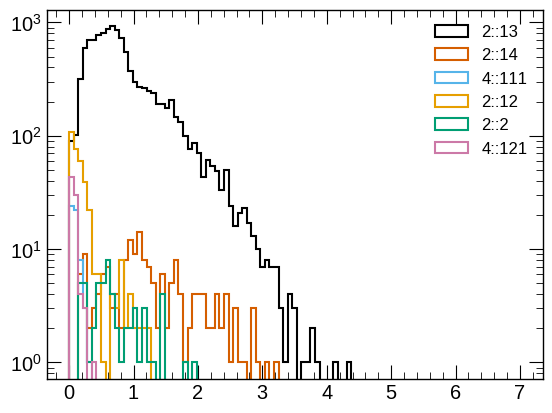

In [154]:
plt.figure()
my_bins = np.linspace(0,7,100)
for proc in E_hit_sum_proc_inelastic:
    if(proc=="-1::-1"):
        continue
    plt.hist(E_hit_sum_proc_inelastic[proc],bins=my_bins,histtype='step',label=proc)

plt.yscale('log')   
plt.legend()
plt.show()

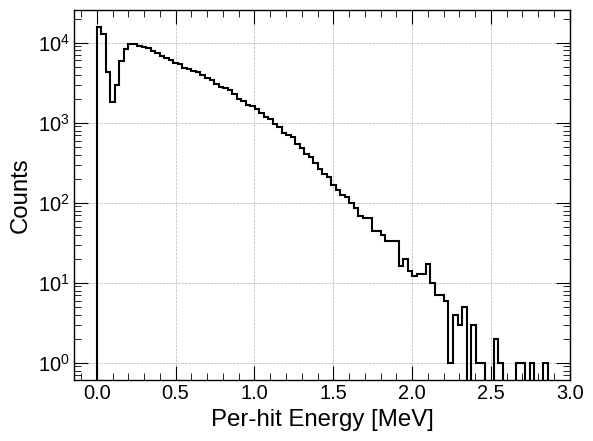

In [147]:
plt.hist(E_hits,bins=100,histtype='step')
plt.xlabel('Per-hit Energy [MeV]')
plt.ylabel('Counts')
plt.yscale('log')
plt.grid()
plt.show()

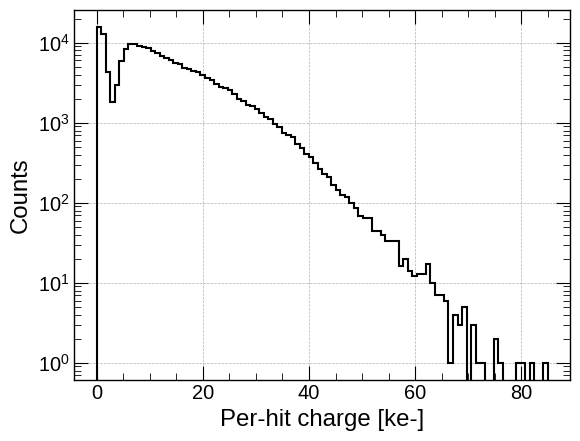

In [148]:
plt.hist(Q_hits,bins=100,histtype='step')
plt.xlabel('Per-hit charge [ke-]')
plt.ylabel('Counts')
plt.yscale('log')
plt.grid()
plt.show()

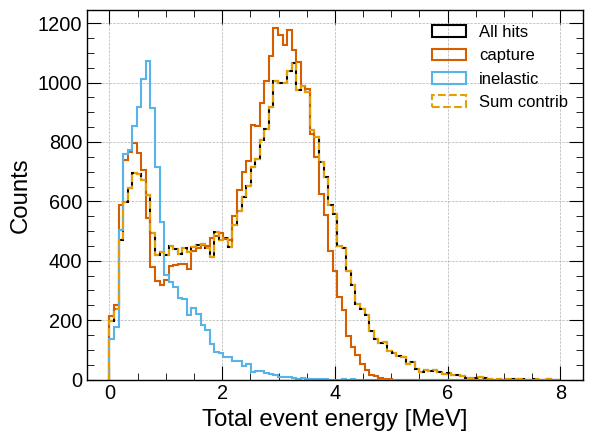

In [149]:
my_binning = np.linspace(0,8,100)

plt.hist(E_sum_hits,bins=my_binning,histtype='step',label='All hits')
plt.hist(E_sum_capture,bins=my_binning,histtype='step',label='capture')
plt.hist(E_sum_inelastic,bins=my_binning,histtype='step',label='inelastic')
#plt.hist(E_sum_neutron,bins=my_binning,histtype='step',label='other')
plt.hist(E_sum_total,bins=my_binning,histtype='step',label='Sum contrib',ls='--')
plt.xlabel('Total event energy [MeV]')
plt.ylabel('Counts')
plt.legend()
#plt.yscale('log')
plt.grid()
plt.show()

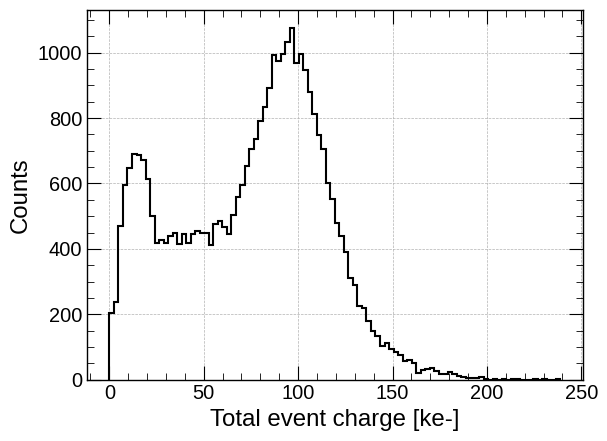

In [150]:
plt.hist(Q_sum_hits,bins=100,histtype='step')
plt.xlabel('Total event charge [ke-]')
plt.ylabel('Counts')
plt.grid()
plt.show()

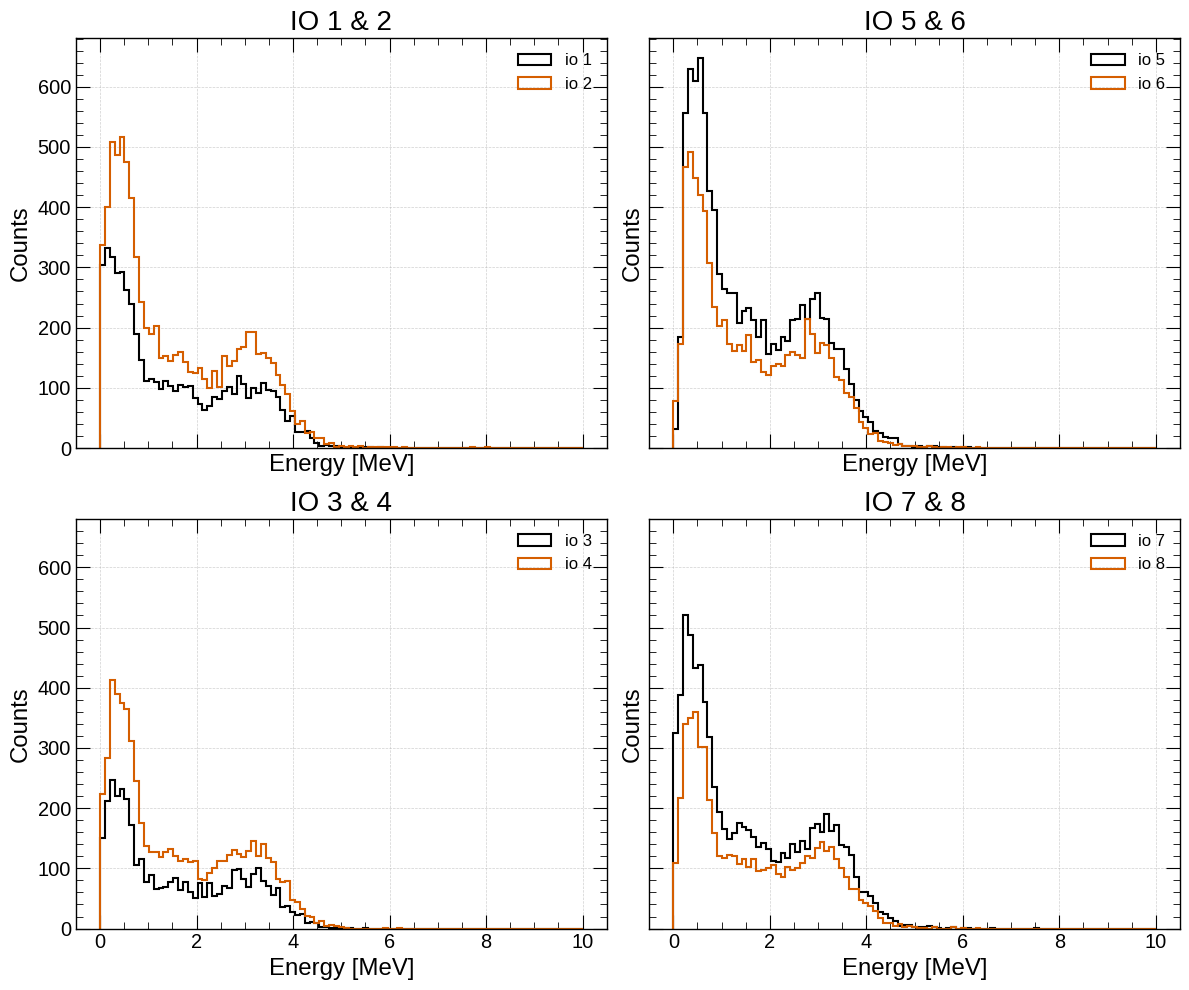

In [151]:
bins = np.linspace(0, 10., 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

# Mapping panels → IO groups
panel_map = {
    (0, 0): [1, 2],   # top left
    (1, 0): [3, 4],   # bottom left
    (0, 1): [5, 6],   # top right
    (1, 1): [7, 8],   # bottom right
}

for (row, col), io_list in panel_map.items():
    ax = axes[row, col]

    for io_val in io_list:
        if io_val in E_cluster_io:
            ax.hist(
                E_cluster_io[io_val],
                bins=bins,
                histtype='step',
                label=f'io {io_val}'
            )

    ax.set_title(f'IO {io_list[0]} & {io_list[1]}',fontsize=20)
    #ax.set_yscale('log')
    ax.set_xlabel('Energy [MeV]')
    ax.set_ylabel('Counts')
    ax.legend()
    ax.grid(alpha=0.6)

plt.tight_layout()
#plt.savefig('E_cluster_low_4panel.png', dpi=200, bbox_inches='tight')
plt.show()

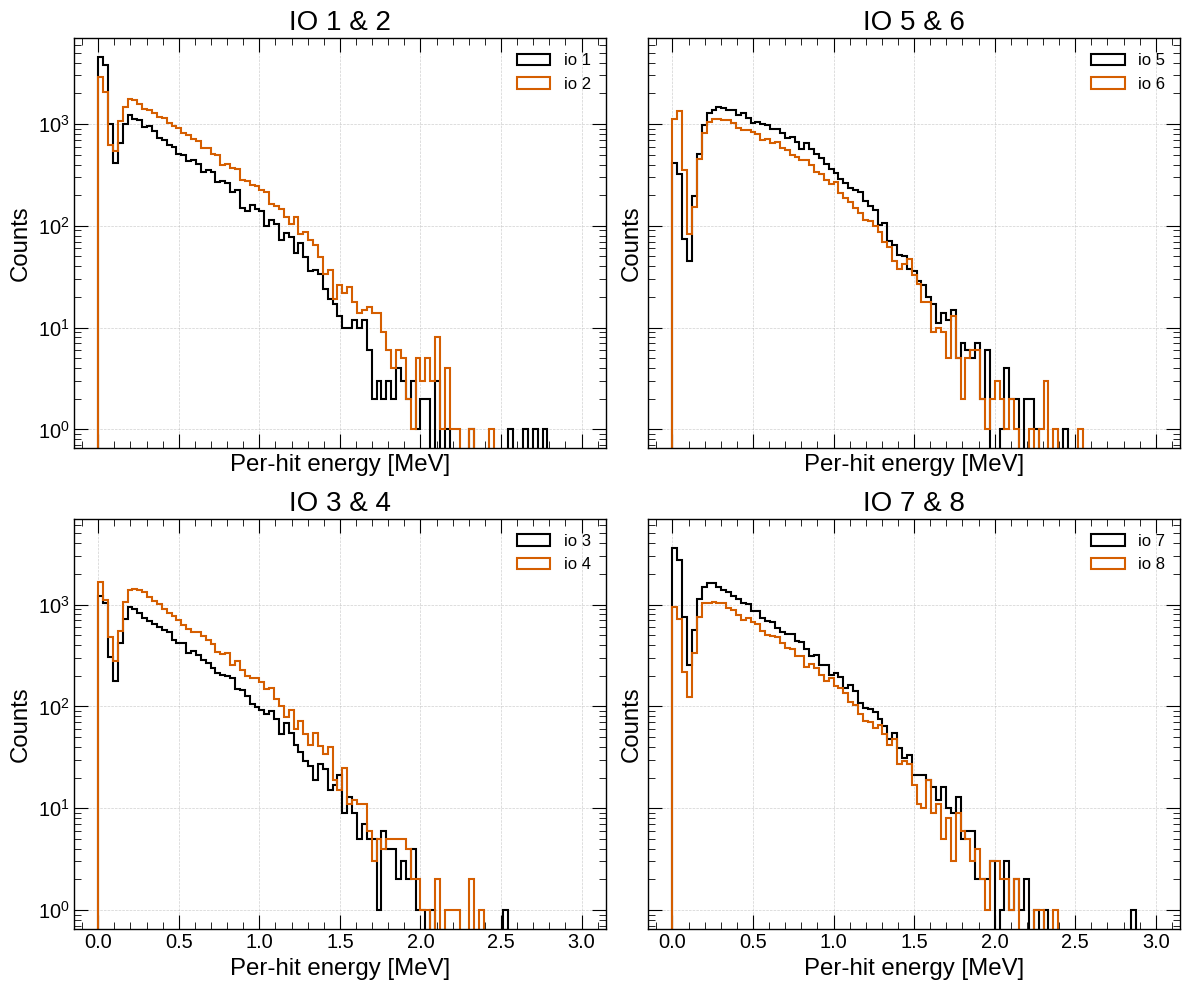

In [152]:
bins = np.linspace(0, 3., 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

# Mapping panels → IO groups
panel_map = {
    (0, 0): [1, 2],   # top left
    (1, 0): [3, 4],   # bottom left
    (0, 1): [5, 6],   # top right
    (1, 1): [7, 8],   # bottom right
}

for (row, col), io_list in panel_map.items():
    ax = axes[row, col]

    for io_val in io_list:
        if io_val in E_hits_io:
            ax.hist(
                E_hits_io[io_val],
                bins=bins,
                histtype='step',
                label=f'io {io_val}'
            )

    ax.set_title(f'IO {io_list[0]} & {io_list[1]}',fontsize=20)
    ax.set_yscale('log')
    ax.set_xlabel('Per-hit energy [MeV]')
    ax.set_ylabel('Counts')
    ax.legend()
    ax.grid(alpha=0.6)

plt.tight_layout()
#plt.savefig('E_cluster_low_4panel.png', dpi=200, bbox_inches='tight')
plt.show()